<a href="https://colab.research.google.com/github/Montasir00/Ml_final_project/blob/monti/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Final Project**

Team members:
1. Pham Gia Khiem - 551026 (Vietnam)
2. Mohammed Hassan – 541140 (Bangladesh)
3. Fazlur Rahman - 541927 (Bangladesh)

### Libraries

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

### I. Understanding the dataset

### Loading the dataset

In [192]:
df = pd.read_csv('data/final_project_dataset_complete.csv', index_col = False)
df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0
...,...,...,...,...,...,...,...,...,...,...,...
8995,0.101630,0.400250,NaN,-0.019412,-0.063150,0.077627,0.540975,-0.169030,Above Average,Region A,0
8996,1.167218,2.177774,-1.716067,1.994835,0.350043,-0.544915,0.089050,-0.944220,High,Region C,1
8997,1.588447,3.333945,-2.615488,3.476880,-0.933276,2.027658,0.239583,1.951491,High,Region C,1
8998,-0.684987,-1.599835,1.063341,-1.252109,-0.724001,2.228943,0.989794,1.936476,Low,Region B,0


In [193]:
# Describe each feature
for column in df.columns:
    print(f"Feature: {column}")
    print(df[column].value_counts() if df[column].dtype == 'object' else df[column].describe())
    print("\n")

Feature: feature_1
count    9000.000000
mean        0.000427
std         1.241318
min       -18.665400
25%        -0.680062
50%        -0.003938
75%         0.680513
max        21.934496
Name: feature_1, dtype: float64


Feature: feature_2
count    9000.000000
mean        0.003349
std         2.508324
min       -37.852816
25%        -1.382610
50%        -0.016698
75%         1.380228
max        47.603454
Name: feature_2, dtype: float64


Feature: feature_3
count    8600.000000
mean        0.003235
std         1.542901
min        -6.676680
25%        -1.022085
50%         0.005196
75%         1.038571
max         6.203055
Name: feature_3, dtype: float64


Feature: feature_4
count    9000.000000
mean       -0.008481
std         2.061784
min        -8.190124
25%        -1.399928
50%        -0.019541
75%         1.394151
max         8.189001
Name: feature_4, dtype: float64


Feature: feature_5
count    9000.000000
mean       -0.002177
std         0.577415
min        -0.999791
25%        -0

In [194]:
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0


In [195]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
count,9000.000000,9000.000000,8600.000000,9000.000000,9000.000000,8500.000000,9000.000000,9000.000000,9000.000000
mean,0.000427,0.003349,0.003235,-0.008481,-0.002177,-0.006447,0.000592,0.003348,0.475444
std,1.241318,2.508324,1.542901,2.061784,0.577415,1.981615,1.075064,2.043643,0.499424
min,-18.665400,-37.852816,-6.676680,-8.190124,-0.999791,-8.590782,-4.422265,-9.474989,0.000000
25%,-0.680062,-1.382610,-1.022085,-1.399928,-0.502614,-1.329040,-0.700078,-1.356620,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000
75%,0.680513,1.380228,1.038571,1.394151,0.497004,1.324897,0.731942,1.402024,1.000000
max,21.934496,47.603454,6.203055,8.189001,0.999914,6.803751,3.857219,7.572578,1.000000


In [196]:
# Checking for missing values
df.isnull().sum()

feature_1       0
feature_2       0
feature_3     400
feature_4       0
feature_5       0
feature_6     500
feature_7       0
feature_8       0
category_1      0
category_2      0
target          0
dtype: int64

In [197]:
# Checking the number of unique values in each column to identify categorical features.
df.nunique()

feature_1     9000
feature_2     9000
feature_3     8600
feature_4     9000
feature_5     9000
feature_6     8500
feature_7     9000
feature_8     9000
category_1       4
category_2       3
target           2
dtype: int64

In [198]:
# Calculates the number of duplicate rows in the DataFrame df.
df.duplicated().sum()

0

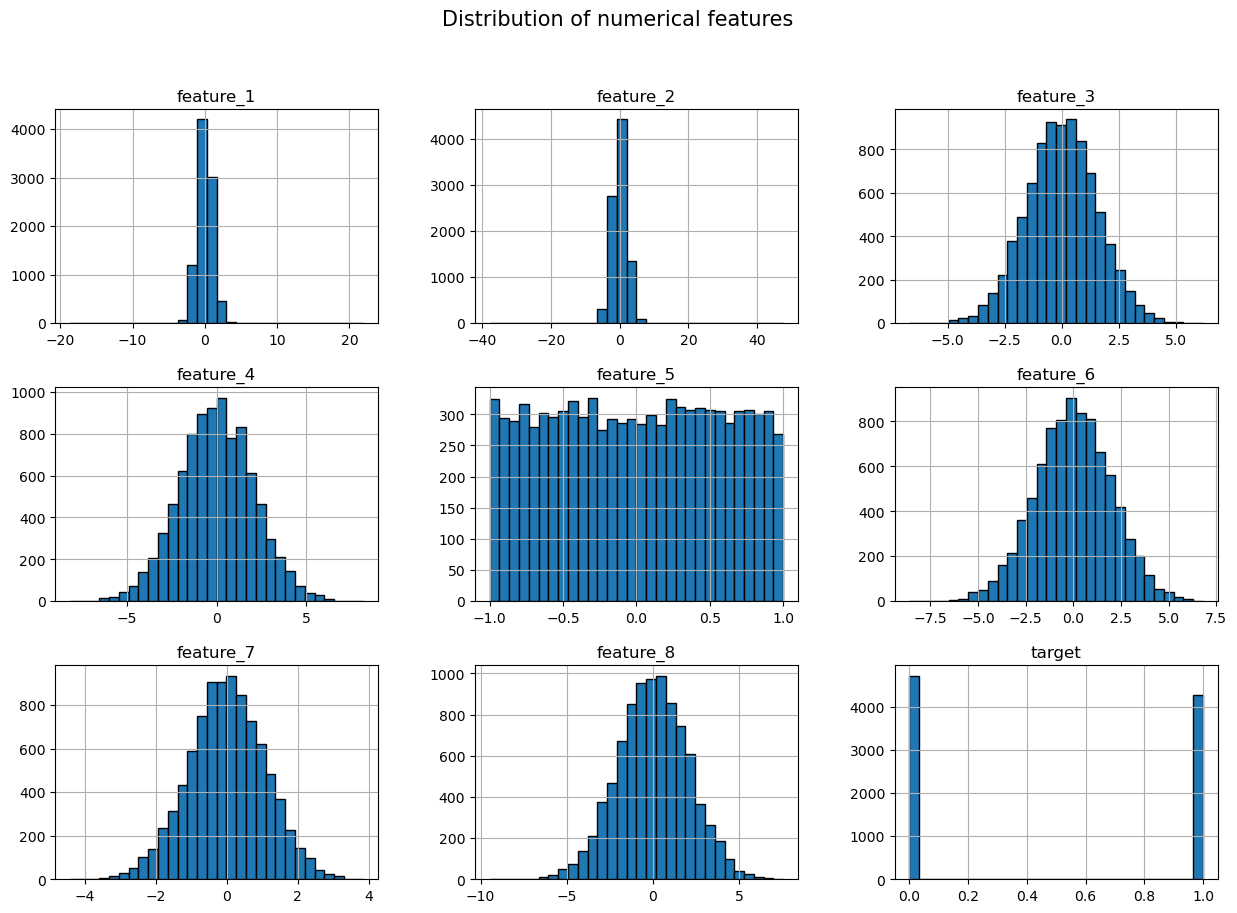

In [199]:
# Visualize the distribution of numerical features in the DataFrame
df.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.suptitle("Distribution of numerical features", fontsize = 15)
plt.show()

Text(0.5, 1.0, 'Box plot of numerical features')

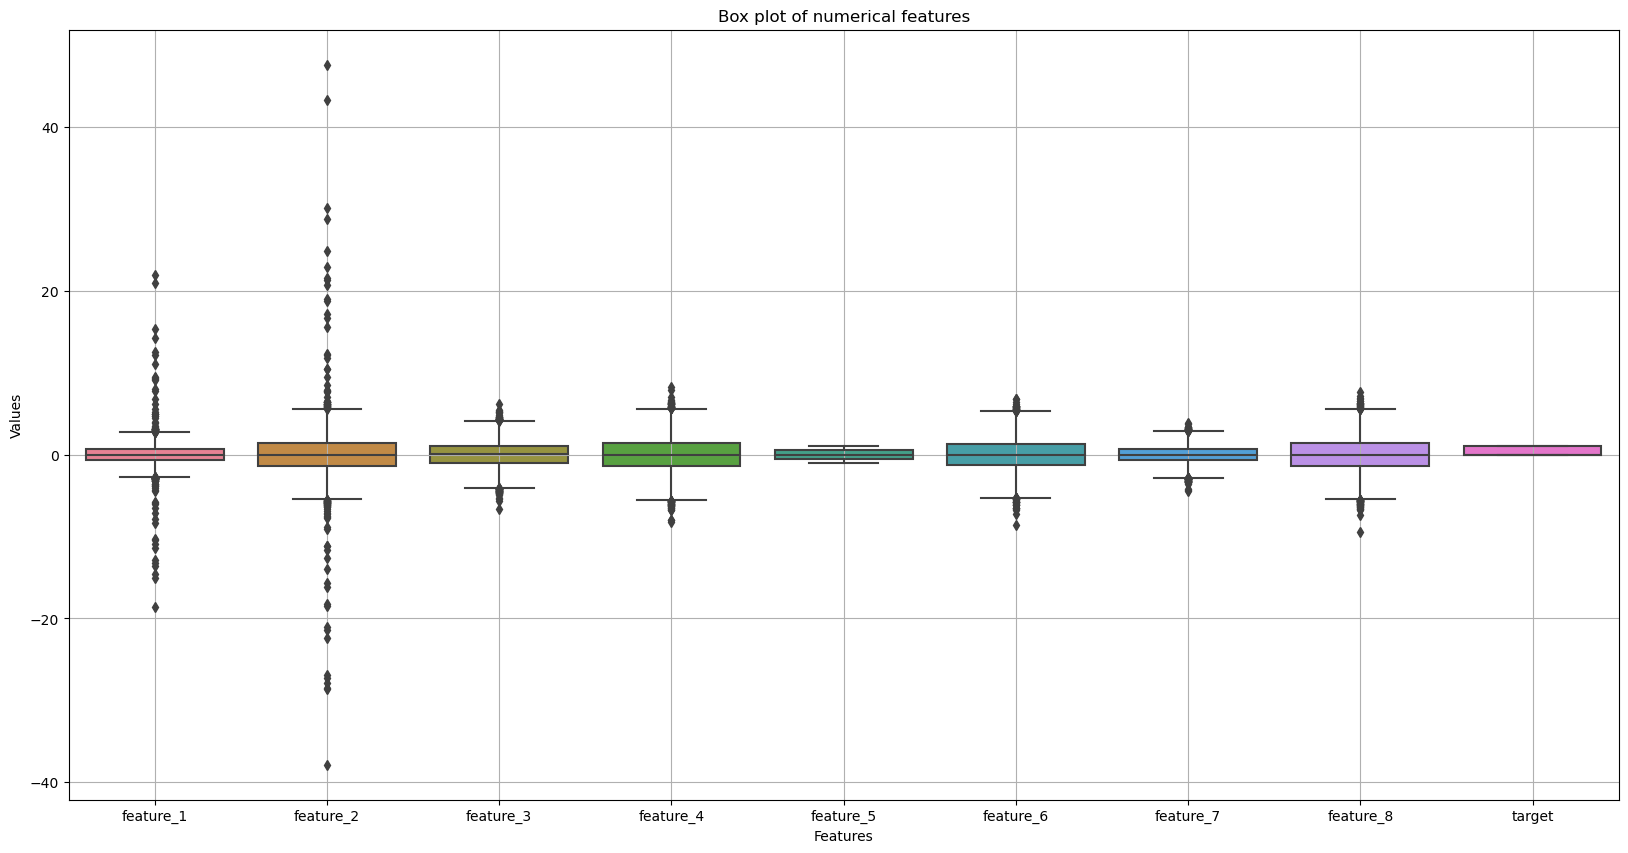

In [200]:
# Visualize the distribution of numerical features in the DataFrame using boxplot
plt.figure(figsize =(20, 10))
sns.boxplot(data = df, palette="husl")
# Add gridlines to the plot
plt.grid(True)

# Add labels and title
plt.xlabel("Features")
plt.ylabel("Values")
plt.title('Box plot of numerical features')

In [201]:
# Select only columns with numerical data types (float64 and int64) 
numeric_df = df.select_dtypes(include=['float64', 'int64'])

In [202]:
numeric_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0


In [203]:
#  Calculating the correlation matrix for the DataFrame
corr_matrix_cleaned = numeric_df.corr()

In [204]:
corr_matrix_cleaned

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
feature_1,1.000000,0.995360,-0.831705,0.831922,-0.015305,-0.010813,-0.010843,-0.004581,0.605940
feature_2,0.995360,1.000000,-0.823242,0.832002,-0.014715,-0.011519,-0.011393,-0.005394,0.606016
feature_3,-0.831705,-0.823242,1.000000,-0.957222,0.011309,0.003989,0.006042,0.001846,-0.704351
feature_4,0.831922,0.832002,-0.957222,1.000000,-0.003613,-0.000213,-0.001369,0.001202,0.694885
feature_5,-0.015305,-0.014715,0.011309,-0.003613,1.000000,-0.009365,0.252371,-0.012717,-0.007873
feature_6,-0.010813,-0.011519,0.003989,-0.000213,-0.009365,1.000000,0.921569,0.969998,0.001457
feature_7,-0.010843,-0.011393,0.006042,-0.001369,0.252371,0.921569,1.000000,0.894220,-0.002000
feature_8,-0.004581,-0.005394,0.001846,0.001202,-0.012717,0.969998,0.894220,1.000000,0.004658
target,0.605940,0.606016,-0.704351,0.694885,-0.007873,0.001457,-0.002000,0.004658,1.000000


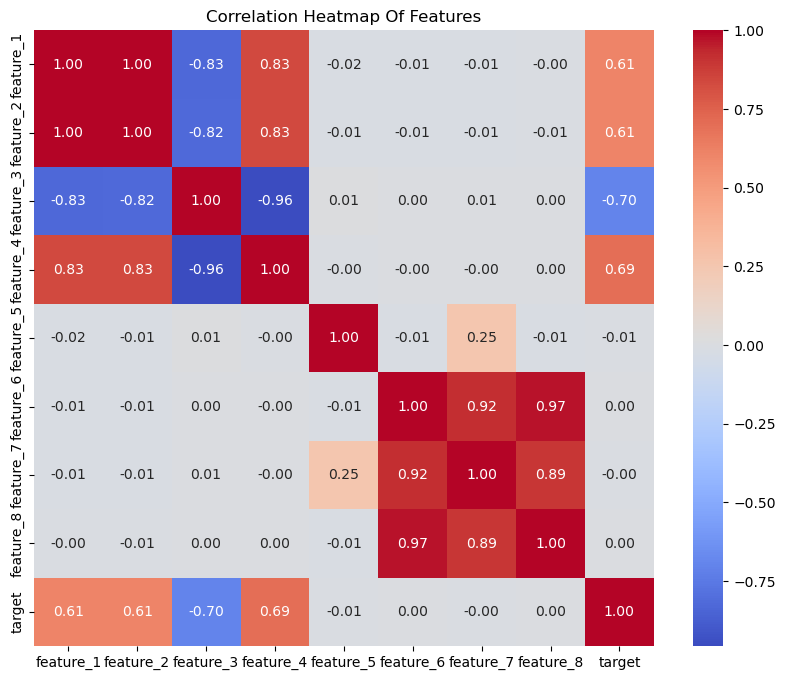

In [205]:
# Visualizing the correlation matrix heatmap
fig = plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix_cleaned, annot=True, cmap ='coolwarm',fmt='0.2f')
plt.title('Correlation Heatmap Of Features')
plt.show()


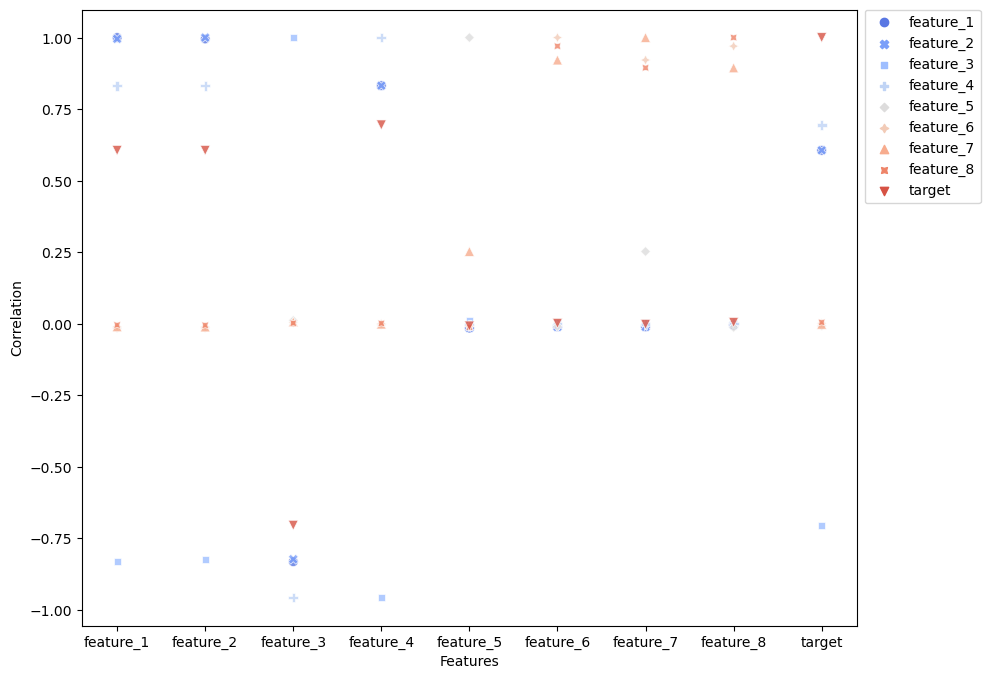

In [206]:
# Create a figure with specified size
fig, ax = plt.subplots(figsize=(10, 8))
# Visualizing the correlation between features and target using scatterplot
sns.scatterplot(data=corr_matrix_cleaned, palette='coolwarm', alpha=0.8, s=50, ax=ax)

ax.set_xlabel('Features')
ax.set_ylabel('Correlation')

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0) 

# Show the plot
plt.show()

### II: Data Preprocessing

In [207]:
# Checking for missing values
df.isna().sum()

feature_1       0
feature_2       0
feature_3     400
feature_4       0
feature_5       0
feature_6     500
feature_7       0
feature_8       0
category_1      0
category_2      0
target          0
dtype: int64

In [208]:
# assigning missing values to a variable
missing_values = df.isna().sum()

# Display columns with missing values
missing_values = missing_values[missing_values > 0]
print(missing_values)

feature_3    400
feature_6    500
dtype: int64


### Handling missing values of Numerical Features

In [209]:
# Using SimpleImputer class to fill in missing values(NaN) with median of each column
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
df['feature_3'] = imputer.fit_transform(df[['feature_3']])
df['feature_6'] = imputer.fit_transform(df[['feature_6']])

In [210]:
# Checking to see if any messing values left or not 
df['feature_3'].isna().sum()
df['feature_6'].isna().sum()

0

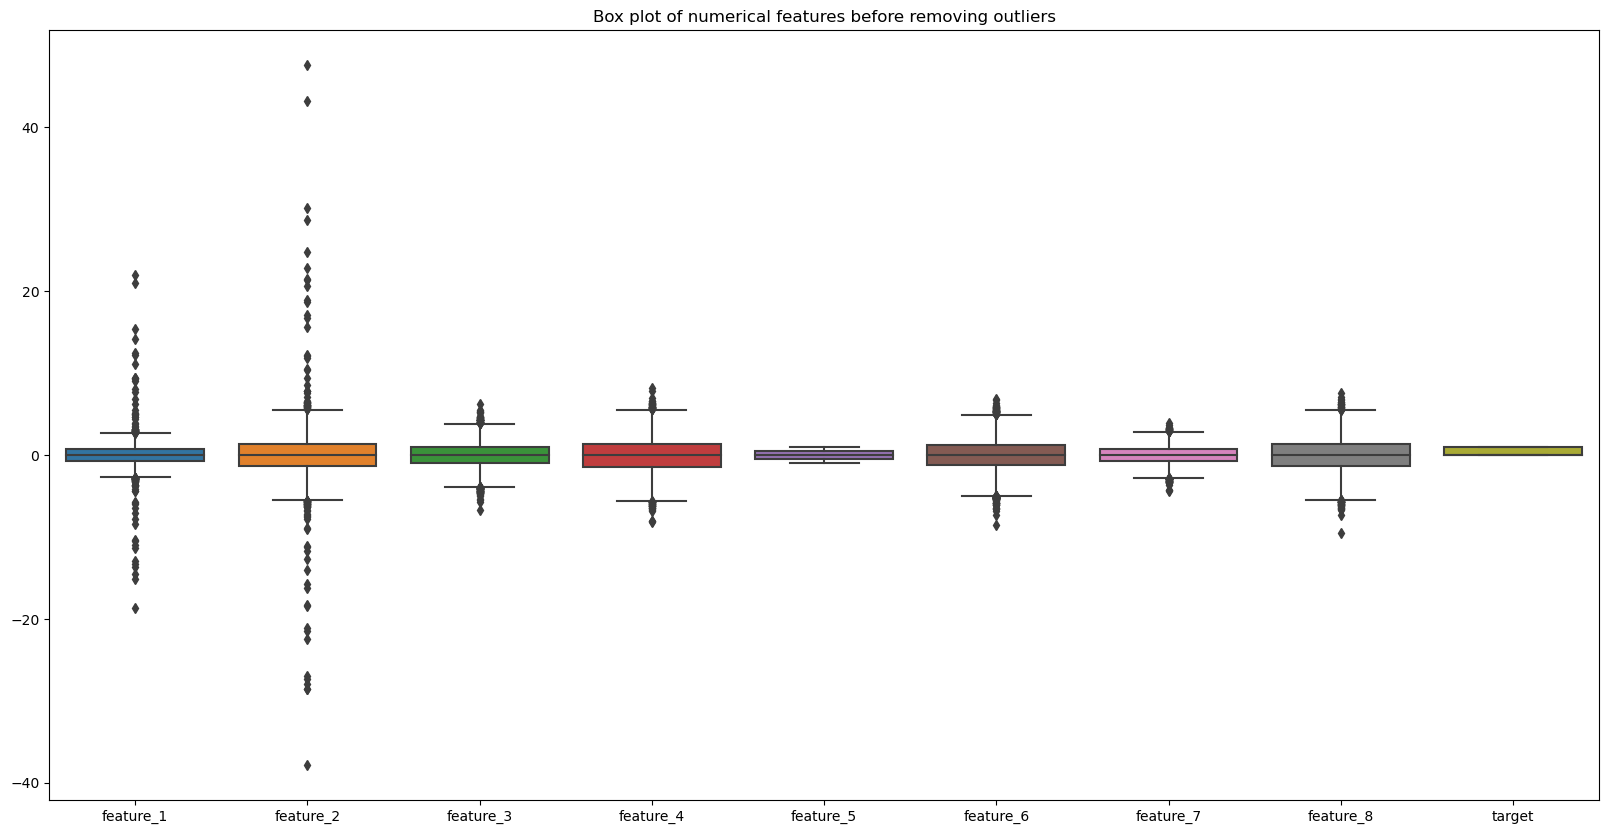

In [211]:
numerical_features = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(20,10))
plt.title('Box plot of numerical features before removing outliers')
sns.boxplot(data=numerical_features)
plt.show()

In [212]:

def iqr_outliers(dataset, feature_name, multiplier= 1.5):
    # Calculate IQR
    Q1 = dataset[feature_name].quantile(0.25)
    Q3 = dataset[feature_name].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate limits
    lower_limit = Q1 - multiplier * IQR
    upper_limit = Q3 + multiplier * IQR
    
    # Identify outliers
    outliers = dataset[(dataset[feature_name] < lower_limit) | (dataset[feature_name] > upper_limit)]
    
    return outliers, {'lower_limit': lower_limit, 'upper_limit': upper_limit}

outliers_detected = {}

for feature in numerical_features.columns:  
    outliers, limits = iqr_outliers(numerical_features, feature)
    outliers_detected[feature] = {
        'count': len(outliers),
        'indices': outliers.index.tolist(),
        'limits': limits
    }
    
    print(f'Feature: {feature}')
    print(f'Number of outliers: {len(outliers)}')
    print(f'Lower limit: {limits["lower_limit"]}, Upper limit: {limits["upper_limit"]}')
    print(f'Outlier indices: {outliers.index.tolist()}')
    print('-' * 50)


Feature: feature_1
Number of outliers: 113
Lower limit: -2.7209235765630777, Upper limit: 2.7213742002161805
Outlier indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1539, 1591, 1615, 1785, 1957, 1971, 2024, 2035, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2521, 2884, 2895, 2947, 3017, 3152, 3227, 3241, 3245, 3336, 3454, 3510, 3569, 3716, 3872, 3982, 3986, 4026, 4029, 4033, 4047, 4091, 4198, 4207, 4265, 4359, 4531, 4617, 4635, 4639, 4725, 4779, 4784, 4870, 4997, 5157, 5224, 5316, 5416, 5488, 5587, 5642, 5649, 5673, 5773, 5796, 5846, 5907, 5935, 5998, 6350, 6408, 6628, 6693, 6738, 6747, 6891, 7060, 7140, 7178, 7223, 7290, 7305, 7330, 7441, 7498, 7611, 7624, 7677, 7839, 7851, 7858, 7872, 7874, 8024, 8067, 8165, 8180, 8200, 8248, 8283, 8354, 8630, 8714, 8726]
--------------------------------------------------
Feature: feature_2
Number of outliers: 106
Lower limit: -5.526868048459379, Upper limit: 5.524485931793154
Outlier indices: [209, 262, 277, 469, 478, 49

In [213]:
df_stage1 = df.copy()
# Loop through the outliers_detected dictionary and replace the outliers with median values

for feature, values in outliers_detected.items():
    # Get outlier indices
    outlier_indices = values['indices']  
    
    # Calculate the median value for the feature
    median_value = df_stage1[feature].median()
    
    # Replace the outlier values with the median value
    df_stage1.loc[outlier_indices, feature] = median_value
    
    # Print out information for verification
    print(f"Feature: {feature}")
    print(f"Replaced outliers in indices: {outlier_indices}")
    print('-' * 50)


Feature: feature_1
Replaced outliers in indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1539, 1591, 1615, 1785, 1957, 1971, 2024, 2035, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2521, 2884, 2895, 2947, 3017, 3152, 3227, 3241, 3245, 3336, 3454, 3510, 3569, 3716, 3872, 3982, 3986, 4026, 4029, 4033, 4047, 4091, 4198, 4207, 4265, 4359, 4531, 4617, 4635, 4639, 4725, 4779, 4784, 4870, 4997, 5157, 5224, 5316, 5416, 5488, 5587, 5642, 5649, 5673, 5773, 5796, 5846, 5907, 5935, 5998, 6350, 6408, 6628, 6693, 6738, 6747, 6891, 7060, 7140, 7178, 7223, 7290, 7305, 7330, 7441, 7498, 7611, 7624, 7677, 7839, 7851, 7858, 7872, 7874, 8024, 8067, 8165, 8180, 8200, 8248, 8283, 8354, 8630, 8714, 8726]
--------------------------------------------------
Feature: feature_2
Replaced outliers in indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1591, 1615, 1785, 1957, 1971, 2024, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2895, 2947, 3017, 3152, 3227, 3

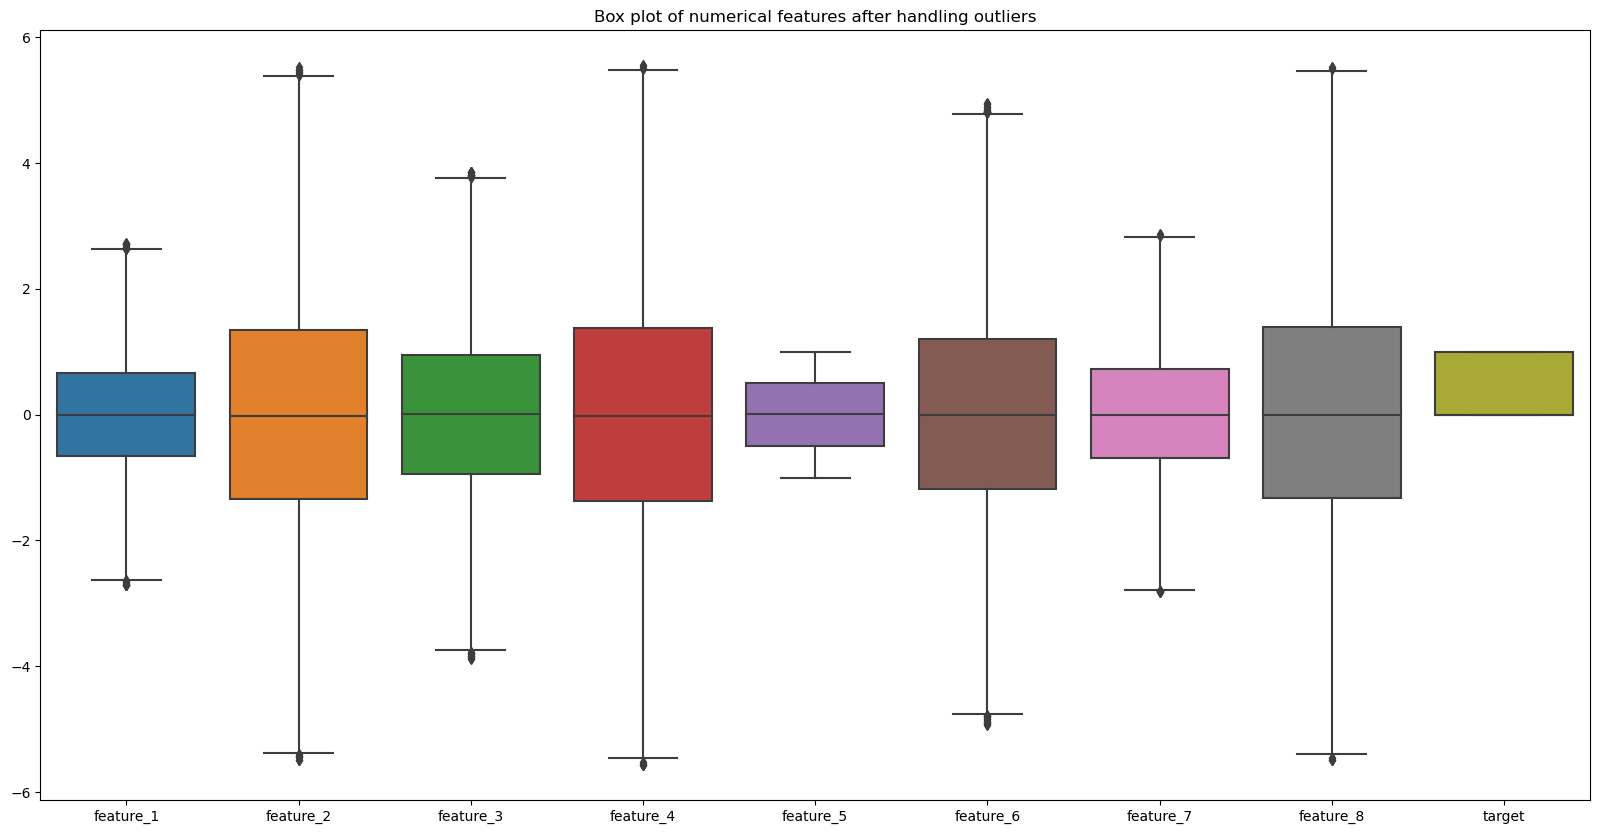

In [214]:
plt.figure(figsize=(20,10))
plt.title('Box plot of numerical features after handling outliers')
sns.boxplot(data=df_stage1)
plt.show()

In [215]:
df_stage1.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,-0.000672,0.002354,0.005988,-0.010226,-0.002177,0.004222,0.006010,0.010578,0.475444
std,0.971927,1.959564,1.429225,1.986669,0.577415,1.818435,1.038181,1.980097,0.499424
min,-2.712613,-5.486925,-3.881410,-5.569645,-0.999791,-4.936580,-2.819977,-5.490152,0.000000
25%,-0.657194,-1.346706,-0.939994,-1.377240,-0.502614,-1.186692,-0.684357,-1.329677,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000
75%,0.659561,1.343450,0.941969,1.368650,0.497004,1.202089,0.720851,1.386503,1.000000
max,2.720169,5.516173,3.854354,5.552331,0.999914,4.950231,2.876070,5.529430,1.000000


#### Lebeling the categorical features

In [216]:
category_columns = df_stage1[['category_1', 'category_2']]

for column in category_columns:
    unique_values = df_stage1[column].unique() 
    unique_count = df_stage1[column].nunique() 
    
    print(f"Column '{column}':")
    print(f"Unique values: {unique_values}")
    print(f"Number of unique options: {unique_count}")
    print('-' * 30)


Column 'category_1':
Unique values: ['Above Average' 'Below Average' 'High' 'Low']
Number of unique options: 4
------------------------------
Column 'category_2':
Unique values: ['Region C' 'Region A' 'Region B']
Number of unique options: 3
------------------------------


In [217]:
# Making a copy of the dataset to avoid changing the original data
df_stage2 = df_stage1.copy()
label_encoder = LabelEncoder()
label_encoder = LabelEncoder()
df_stage2['cat_1_encoded'] = label_encoder.fit_transform(df_stage2['category_1'])
# One-Hot Encoding for category_2 (nominal)
df_one_hot = pd.get_dummies(df_stage2['category_2'])

# Combine the original dataframe with the one-hot encoded dataframe
df_stage2 = pd.concat([df_stage2, df_one_hot], axis=1)

# Drop the original category_2 column if no longer needed
df_stage2.drop(columns=['category_1', 'category_2'], inplace=True)

# Display the final dataframe
df_stage2.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,cat_1_encoded,Region A,Region B,Region C
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1,0,False,False,True
1,-0.138264,-0.061846,0.005196,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0,1,True,False,False
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1,2,False,False,True
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1,2,False,True,False
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0,1,False,False,True


In [218]:
print(f'Before changing column names:\n {df_stage2.columns}')

# Renaming columns
df_stage2.rename(columns={
    'Region A': 'region_A',
    'Region B': 'region_B',
    'Region C': 'region_C'
}, inplace=True)

# Verify column names
print(f'After changing column names:\n {df_stage2.columns}')


Before changing column names:
 Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       'feature_6', 'feature_7', 'feature_8', 'target', 'cat_1_encoded',
       'Region A', 'Region B', 'Region C'],
      dtype='object')
After changing column names:
 Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       'feature_6', 'feature_7', 'feature_8', 'target', 'cat_1_encoded',
       'region_A', 'region_B', 'region_C'],
      dtype='object')


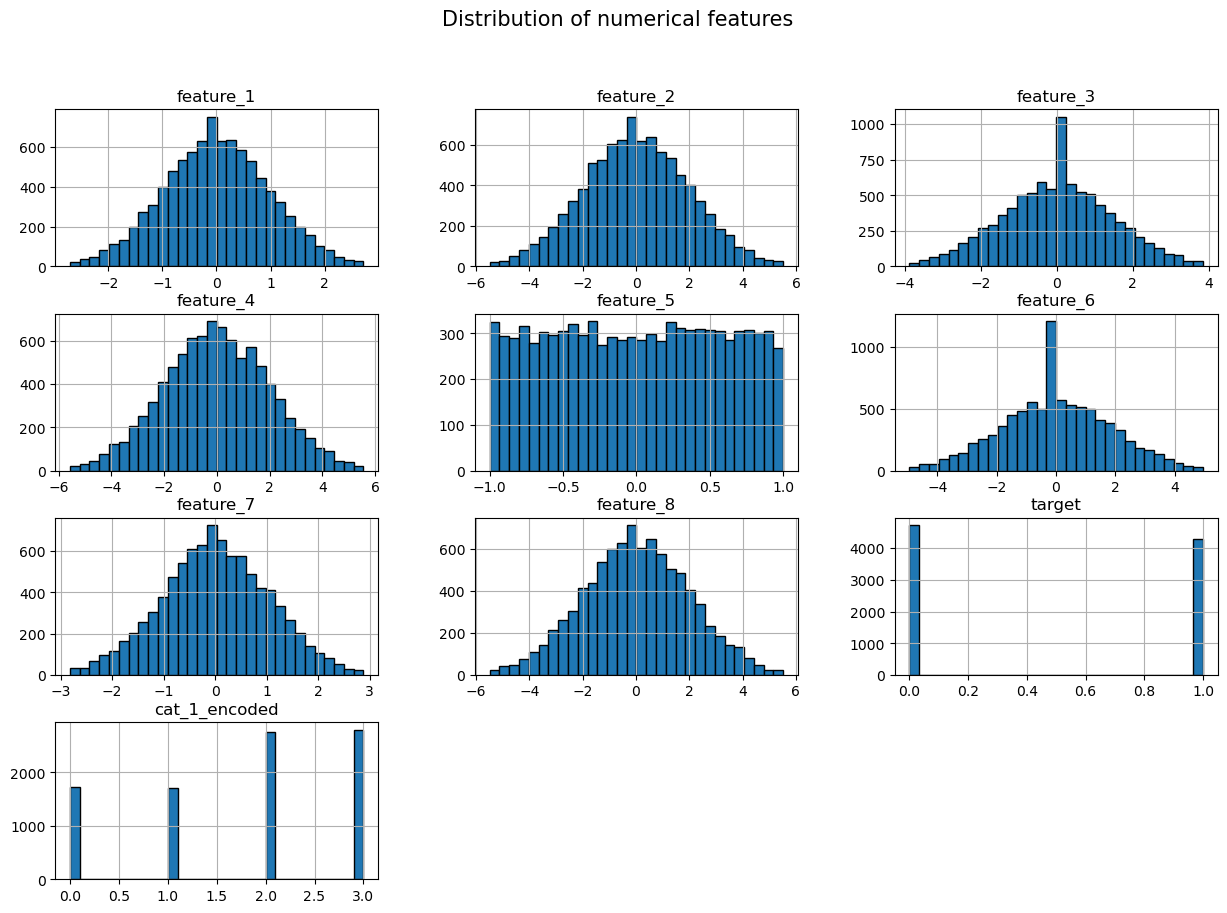

In [219]:
df_stage2.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.suptitle("Distribution of numerical features", fontsize = 15)
plt.show()

In [220]:
df_stage2.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,cat_1_encoded
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,-0.000672,0.002354,0.005988,-0.010226,-0.002177,0.004222,0.006010,0.010578,0.475444,1.737778
std,0.971927,1.959564,1.429225,1.986669,0.577415,1.818435,1.038181,1.980097,0.499424,1.095463
min,-2.712613,-5.486925,-3.881410,-5.569645,-0.999791,-4.936580,-2.819977,-5.490152,0.000000,0.000000
25%,-0.657194,-1.346706,-0.939994,-1.377240,-0.502614,-1.186692,-0.684357,-1.329677,0.000000,1.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000,2.000000
75%,0.659561,1.343450,0.941969,1.368650,0.497004,1.202089,0.720851,1.386503,1.000000,3.000000
max,2.720169,5.516173,3.854354,5.552331,0.999914,4.950231,2.876070,5.529430,1.000000,3.000000


In [221]:
df_stage2.to_csv('C:/Users/fazlu/OneDrive/Desktop/projects/Machine_learning_project/Ml_final_project/data/cleaned_dataset.csv')

#### III. EDA (EXPLORATRY DATA ANALYSIS)

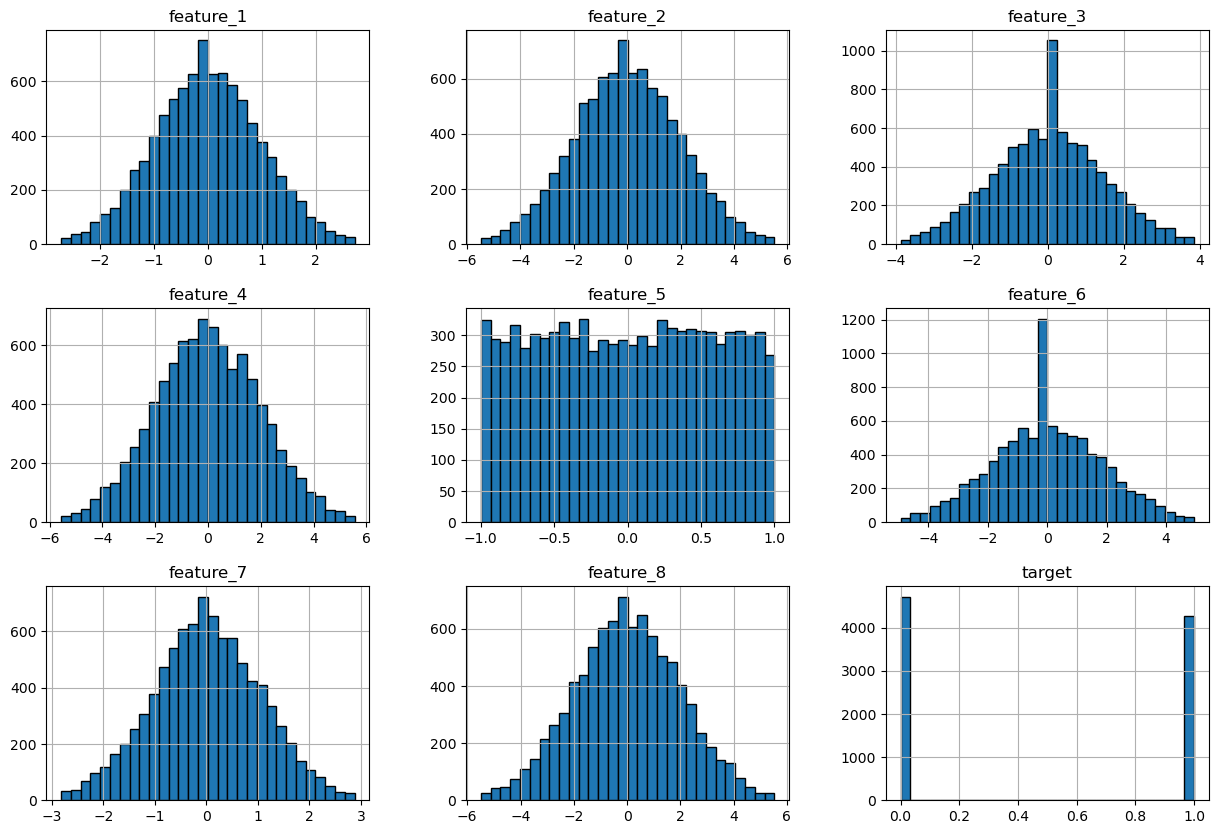

In [222]:
df_stage1.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.show()

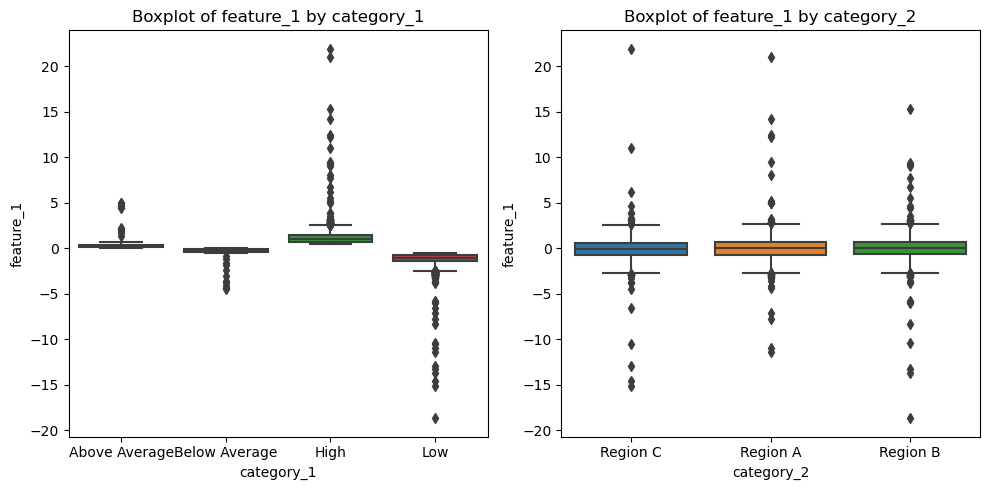

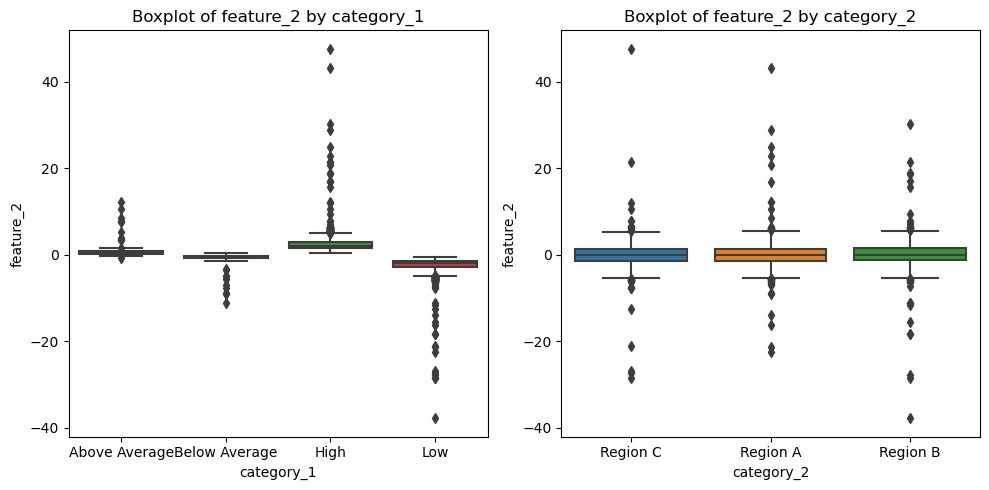

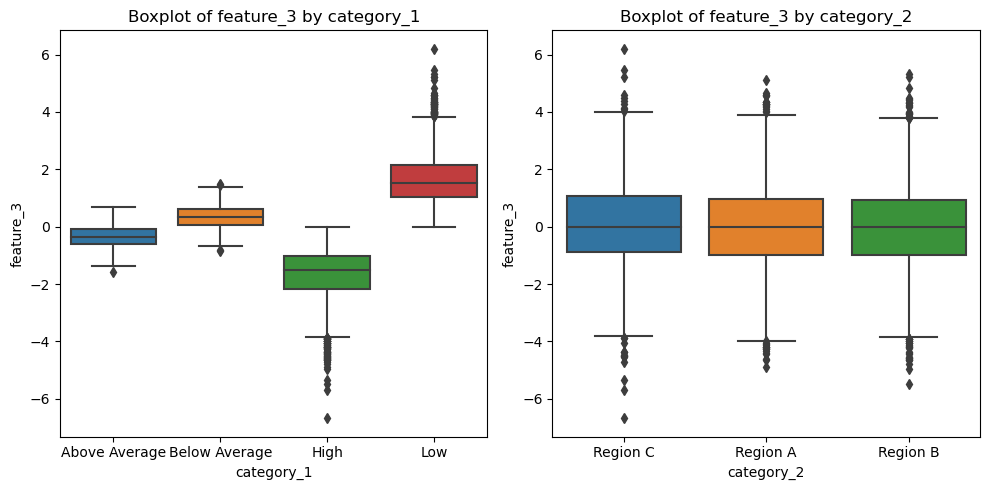

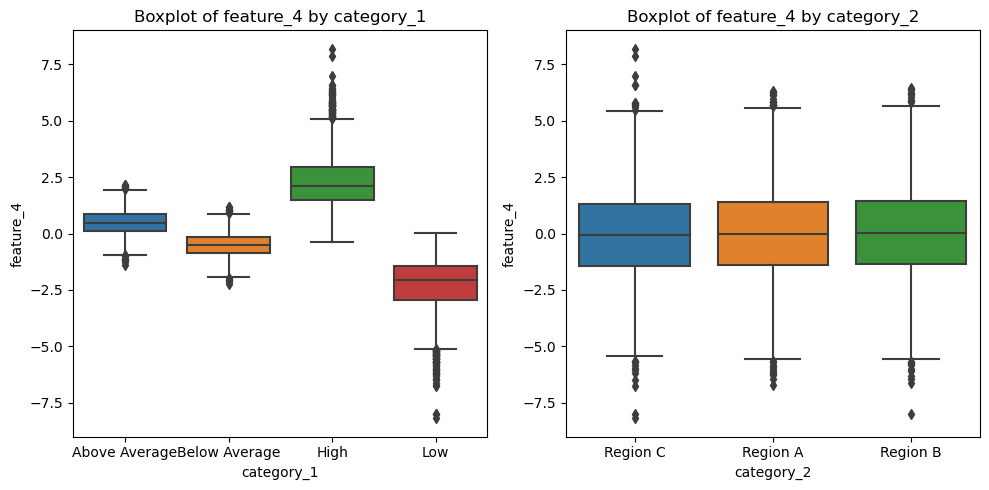

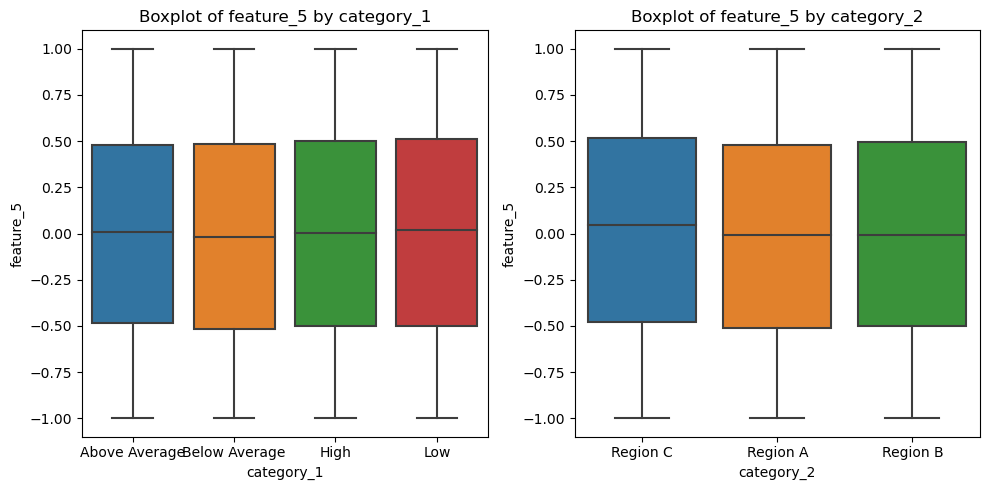

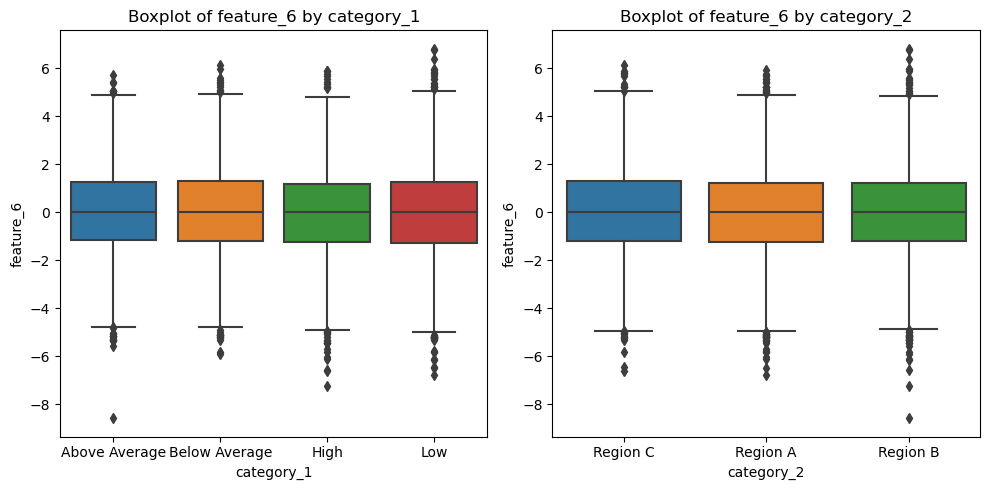

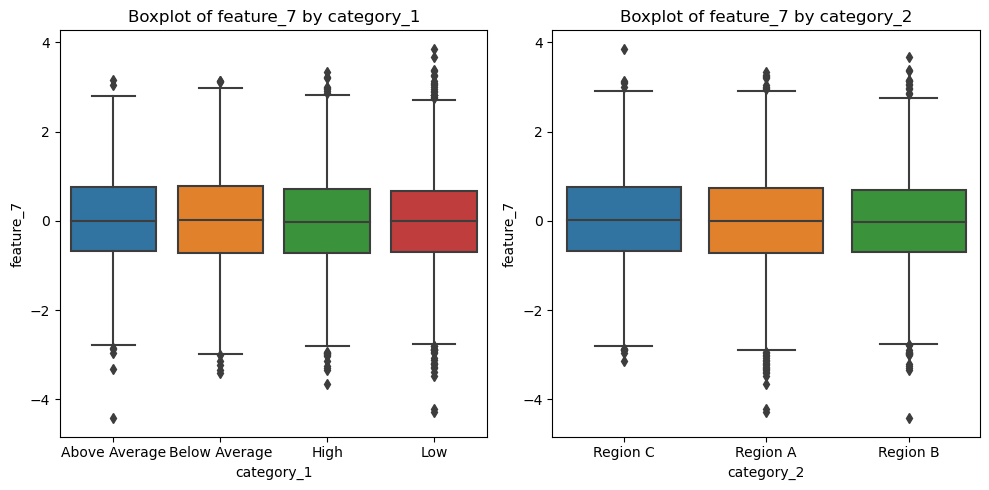

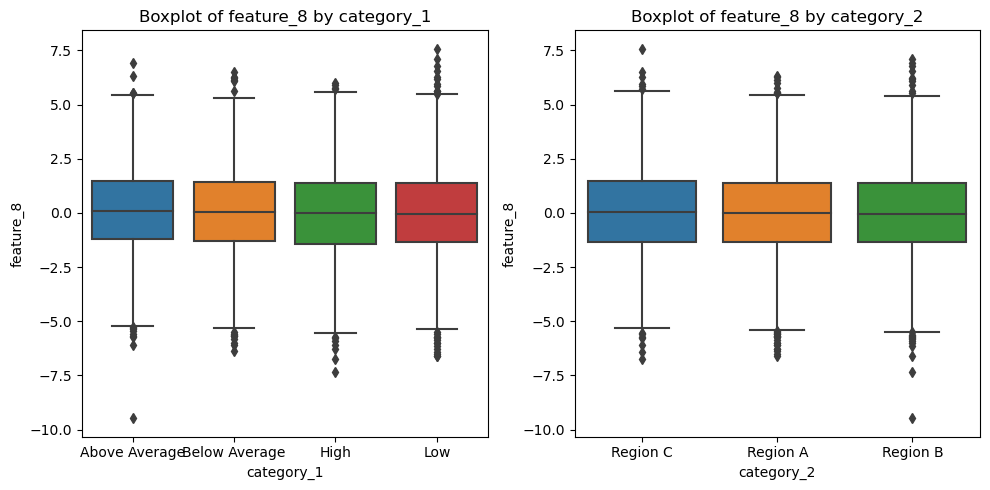

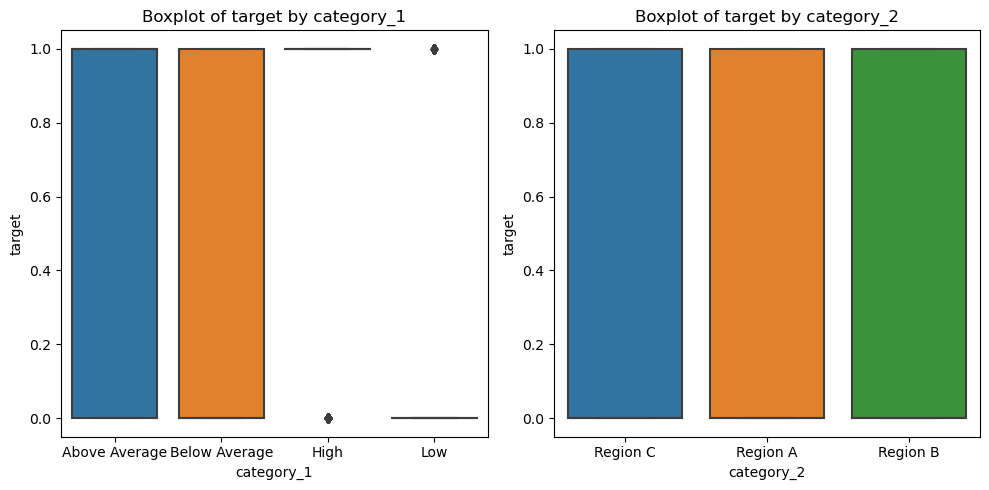

In [223]:
for column in numerical_features:
    plt.figure(figsize=(10, 5))
    
    # Boxplot by category_1
    plt.subplot(1, 2, 1)  # Creates 1 row and 2 columns of subplots, and the first one is selected
    sns.boxplot(x='category_1', y=column, data=df)
    plt.title(f'Boxplot of {column} by category_1')
    
    # Boxplot by category_2
    plt.subplot(1, 2, 2)  # Select the second subplot
    sns.boxplot(x='category_2', y=column, data=df)
    plt.title(f'Boxplot of {column} by category_2')
    
    plt.tight_layout()  # Adjust the layout for better spacing
    plt.show()

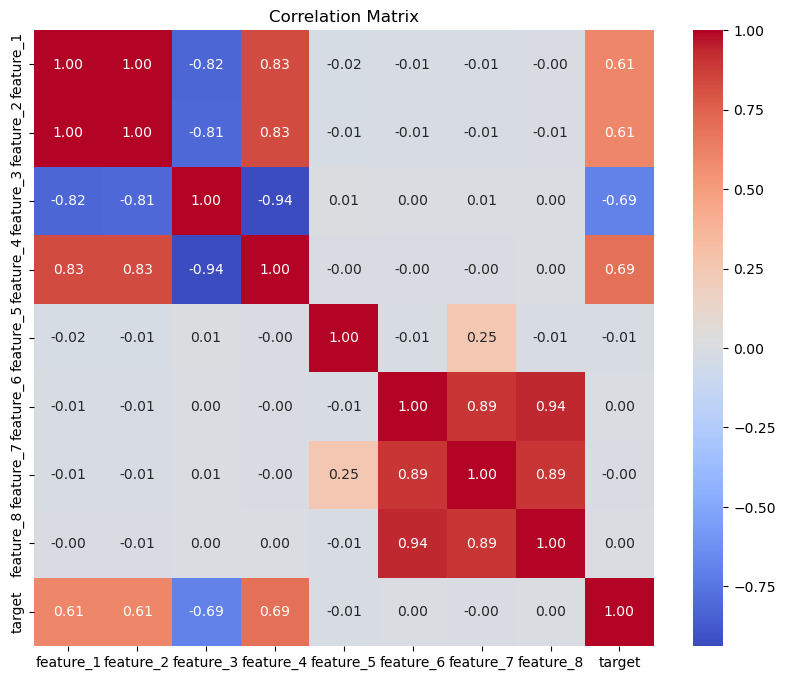

In [224]:
correlation_matrix = numerical_features.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [225]:
# Performing t-tests for each numerical feature against the target variable
results = {}

for feature in numeric_df[:-1]:  # Exclude the target variable
    group1 = df[df['target'] == 1][feature].dropna()
    group0 = df[df['target'] == 0][feature].dropna()
    t_stat, p_value = stats.ttest_ind(group1, group0)
    results[feature] = {'t_statistic': t_stat, 'p_value': p_value}

# Converting results to a DataFrame for better visualization
results_df = pd.DataFrame(results).T
results_df.index.name = 'Feature'

# Displaying the t-test results
print(results_df)

           t_statistic   p_value
Feature                         
feature_1    72.253084  0.000000
feature_2    72.267409  0.000000
feature_3   -90.276861  0.000000
feature_4    91.660903  0.000000
feature_5    -0.746804  0.455201
feature_6     0.134524  0.892991
feature_7    -0.189743  0.849515
feature_8     0.441833  0.658621
target             inf  0.000000


C:\Users\fazlu\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [226]:
# Performing chi-square tests for categorical variables against the target variable
chi_square_results = {}

# Chi-square test for category_1
contingency_table_1 = pd.crosstab(df['category_1'], df['target'])
chi2_stat_1, p_value_1, dof_1, expected_1 = stats.chi2_contingency(contingency_table_1)
chi_square_results['category_1'] = {'chi2_statistic': chi2_stat_1, 'p_value': p_value_1}

# Chi-square test for category_2
contingency_table_2 = pd.crosstab(df['category_2'], df['target'])
chi2_stat_2, p_value_2, dof_2, expected_2 = stats.chi2_contingency(contingency_table_2)
chi_square_results['category_2'] = {'chi2_statistic': chi2_stat_2, 'p_value': p_value_2}

# Converting results to a DataFrame for better visualization
chi_square_results_df = pd.DataFrame.from_dict(chi_square_results, orient='index')
chi_square_results_df.index.name = 'Category'

# Displaying the chi-square test results
print(chi_square_results_df)

            chi2_statistic  p_value
Category                           
category_1     5175.320287  0.00000
category_2        1.319349  0.51702


### IV. FEATURE ENGINEERING

In [227]:
df_stage3 = df_stage2.copy()

# Function to engineer new features
def feature_engineering(df_stage3):
    # Drop unnecessary features
    df_stage3 = df_stage3.drop(['feature_7', 'feature_8', 'feature_5'], axis=1)
    
    # Create a new feature based on existing ones
    df_stage3['feature_9'] = df_stage3['feature_1'] * df_stage3['feature_4']
    
    return df_stage3

# Apply feature engineering
df_stage3 = feature_engineering(df_stage3)

# Display the first few rows of the modified DataFrame
df_stage3.head()

,feature_1,feature_2,feature_3,feature_4,feature_6,target,cat_1_encoded,region_A,region_B,region_C,feature_9
0,0.496714,1.146509,-0.648521,0.833005,-2.209437,1,0,False,False,True,0.413765
1,-0.138264,-0.061846,0.005196,0.403768,-2.498565,0,1,True,False,False,-0.055827
2,0.647689,1.395115,-0.764126,1.708266,1.956259,1,2,False,False,True,1.106424
3,1.523030,2.657560,-2.461653,2.649051,3.445638,1,2,False,True,False,4.034584
4,-0.234153,-0.499391,0.576097,-0.441656,0.211425,0,1,False,False,True,0.103415


In [229]:
df_stage4 = df_stage3.copy()

scaler = MinMaxScaler()

# Loop through each numerical feature and apply MinMax scaling
for feature in df_stage4:
    df_stage4[feature] = scaler.fit_transform(df_stage4[[feature]])

# Display the first few rows of the normalized dataset
print(df_stage4.head())

   feature_1  feature_2  feature_3  feature_4  feature_6  target  \
0   0.590734   0.602870   0.417915   0.575676   0.275836     1.0   
1   0.473855   0.493050   0.502421   0.537082   0.246593     0.0   
2   0.618523   0.625464   0.402970   0.654372   0.697175     1.0   
3   0.779645   0.740199   0.183532   0.738960   0.847818     1.0   
4   0.456204   0.453284   0.576221   0.461068   0.520694     0.0   

   cat_1_encoded  region_A  region_B  region_C  feature_9  
0       0.000000       0.0       0.0       1.0   0.091154  
1       0.333333       1.0       0.0       0.0   0.061612  
2       0.666667       0.0       0.0       1.0   0.134728  
3       0.666667       0.0       1.0       0.0   0.318937  
4       0.333333       0.0       0.0       1.0   0.071630  


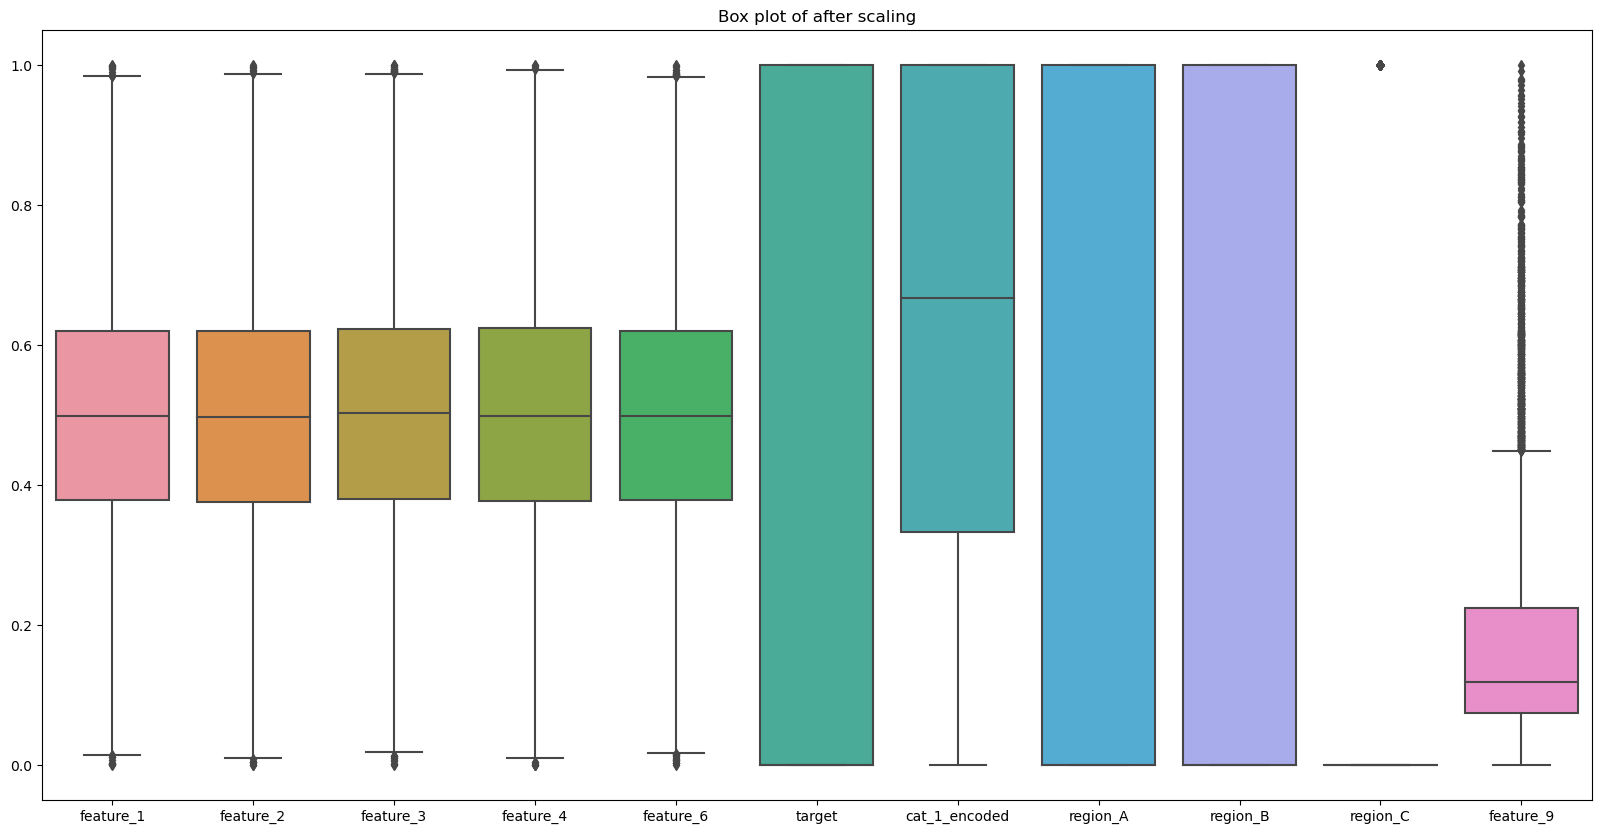

In [231]:
plt.figure(figsize=(20,10))
plt.title('Box plot of after scaling')
sns.boxplot(data=df_stage4)
plt.show()

### V. Modeling

In [232]:
X = df_stage4.drop('target', axis = 1)
y = df_stage4['target']

In [233]:
def select_features(X, y):
    model = RandomForestClassifier(random_state=42)
    rfe = RFE(model, n_features_to_select=8)
    X_final = rfe.fit_transform(X, y)
    final_features = X.columns[rfe.get_support()]
    print(final_features)
    return final_features

In [234]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(len(X_train))
print(len(X_test))

7200
1800


In [235]:
selected_features = select_features(X_train, y_train)
X_test = X_test[selected_features]
X_train = X_train[selected_features]

#print(X_train, X_test)
print(len(X_train))
print(len(X_test))

Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_6',
       'cat_1_encoded', 'region_A', 'feature_9'],
      dtype='object')
7200
1800


In [236]:
def split_train_test(data, test_ratio):
  np.random.seed(42)
  shuffled_indices = np.random.permutation(len(data))
  test_set_size = int(len(data) * test_ratio)
  test_indices = shuffled_indices[:test_set_size]
  train_indices = shuffled_indices[test_set_size:]
  return data.iloc[train_indices], data.iloc[test_indices]

In [237]:
train_set, test_set = split_train_test(df_stage4, 0.2)
print(len(train_set))
print(len(test_set))

7200
1800


In [238]:
def evaluate_model(model, param_grid, X_train, y_train, X_test, y_test):
    # GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    # Training the model with the best parameters
    best_model = grid_search.best_estimator_

    # Predictions
    predictions = best_model.predict(X_test)

    # Best parameters
    best_parameters = grid_search.best_params_
    print("Best Parameters:", best_parameters)

    print("Classification Report:")
    print(classification_report(y_test, predictions))

    # Evaluation
    conf_matrix = confusion_matrix(y_test, predictions)

    # Visualization of Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu", fmt='g')
    plt.title('Confusion matrix')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

    return best_model

In [239]:
# Check overfitting
def check_overfitting(model, X_train, y_train, X_test, y_test):
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")

In [240]:
def feature_importance(model, selected_features):
    # Feature importances from Best Random Forest
    importances = model.feature_importances_
    feature_names = X[selected_features].columns
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    print(feature_importance_df.sort_values(by='importance', ascending=False))